# Model-free baseline comparison

## Holistic approach

Compare **Scalarized UCB**, **Scalarized KG**, and **Pareto UCB** under RTS and STR in the standard setting: $\gamma_{\mathrm{sync}}=\gamma_{\mathrm{grav}}=\gamma_{\mathrm{heter}}=1$, $M=40$ octopi, four classes, and simulated rewards.

All algorithms have **7 fitness-margin arms** and **150 online global iterations**. Scalarized UCB and KG use **7 scalarization directions** and retain their existing SPA definitions. Pareto UCB maximizes negative normalized costs using the notebook's mean-plus-confidence rule.

**Feedback differs by design:** UCB/KG use the current overhead and instability increments. Pareto UCB attributes $(\Delta O_t,\Delta I_{t+1})$ to the arm selected at global iteration $t$. This pair becomes available only after iteration $t+1$. Its final action remains pending, giving **149 completed observations** within the 150-iteration budget; no extra step or fabricated final instability is used.

Each final learned arm set supplies **20 common random sequence draws**, with a threshold drawn uniformly from that set at every iteration. Duplicate sequences are removed. Each sequence is evaluated over **100 global iterations** on the same **10 held-out seeds**. There is one training run per algorithm/formulation. Pareto UCB learns one set, which is evaluated under both RTS and STR.


### Load the saved comparison

These cells load and score existing measurements. They do not run training or simulation. All experimental parameters and calibration matrices are embedded in `Model-free baseline/setup_model_free_holistic.json`.


In [1]:
from pathlib import Path
import hashlib
import importlib.util
import pickle
import sys
sys.dont_write_bytecode = True
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

project_root = next(root for root in (Path.cwd(), *Path.cwd().parents)
                    if (root / "Model-free baseline" / "evaluate_holistic_comparison.py").is_file())
experiment_dir = project_root / "Model-free baseline"
sys.path.insert(0, str(experiment_dir))
spec = importlib.util.spec_from_file_location("_model_free_baseline_evaluation", experiment_dir / "evaluate_holistic_comparison.py")
comparison = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = comparison
spec.loader.exec_module(comparison)
with (experiment_dir / "holistic hypervolume comparison.pkl").open("rb") as file:
    result = pickle.load(file)
assert result["complete"] and result["kind"] == "holistic_model_free_baseline_comparison"
comparison.check_sources(result)
costs = np.asarray(result["cost_realizations"])
assert costs.shape == (len(result["unit_sequences"]), 10, 2)
assert np.isfinite(costs).all() and (costs >= 0).all()
display(Markdown(f"**Completed evaluation:** {costs.shape[0]} unique sequences x {costs.shape[1]} shared realizations = **{costs.shape[0]*costs.shape[1]:,} simulations**."))


Using device: cuda
GPU: NVIDIA RTX A2000 8GB Laptop GPU


C:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\.venv\Lib\site-packages\torch\jit\_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


**Completed evaluation:** 100 unique sequences x 10 shared realizations = **1,000 simulations**.

### Hypervolume definitions

Minimize total overhead and total instability, dividing by the fixed reference **(2,200,000 KiB, 310)**. The normalized reference is **(1, 1)** for all six bars.

- **RTS:** average each sequence's 10 cost realizations and compute the exact two-dimensional dominated area of the resulting mean-cost vectors.
- **STR:** average each sequence's reference-based length scores over those realizations, then take the upper envelope across sequences and integrate using the existing 128-direction midpoint rule.
- **Pareto UCB:** apply both definitions to its **same learned arm set, same sampled sequences, and same measured costs**. These are two evaluation formulations, not two Pareto UCB training variants.

These are finite sampled-set hypervolumes. The 20 sequence draws approximate the set of sequences available from the recommended arms; they are not 20 independent training runs or a single averaged random policy.


In [2]:
summary = comparison.statistics(result)
np.testing.assert_allclose([row["hypervolume"] for row in summary],
                           [row["hypervolume"] for row in result["summary"]], rtol=1e-12, atol=1e-14)
assert len(summary) == 6
table = ["| Algorithm | Formulation | Recommended arm indices | Unique sequences | Realizations per sequence | Hypervolume |",
         "|:--|:--|:--|--:|--:|--:|"]
for row in summary:
    table.append(f"| {row['algorithm']} | {row['formulation']} | {row['recommended_arm_indices'].tolist()} | {row['n_solutions']} | {row['n_realizations']} | {row['hypervolume']:.6f} |")
display(Markdown("\n".join(table)))


| Algorithm | Formulation | Recommended arm indices | Unique sequences | Realizations per sequence | Hypervolume |
|:--|:--|:--|--:|--:|--:|
| Scalarized UCB | RTS | [0, 2, 4] | 20 | 10 | 0.589618 |
| Scalarized KG | RTS | [0, 1, 2, 3, 4] | 20 | 10 | 0.596447 |
| Pareto UCB | RTS | [0, 1, 2, 3, 4, 6] | 20 | 10 | 0.613905 |
| Scalarized UCB | STR | [0, 1, 4, 6] | 20 | 10 | 0.634191 |
| Scalarized KG | STR | [1, 2, 3, 4] | 20 | 10 | 0.617152 |
| Pareto UCB | STR | [0, 1, 2, 3, 4, 6] | 20 | 10 | 0.613296 |

### Holistic hypervolume comparison

Three algorithms appear in each formulation group. The shared vertical axis starts at zero; higher hypervolume is better. Only Pareto UCB uses the explicitly requested next-iteration instability feedback.


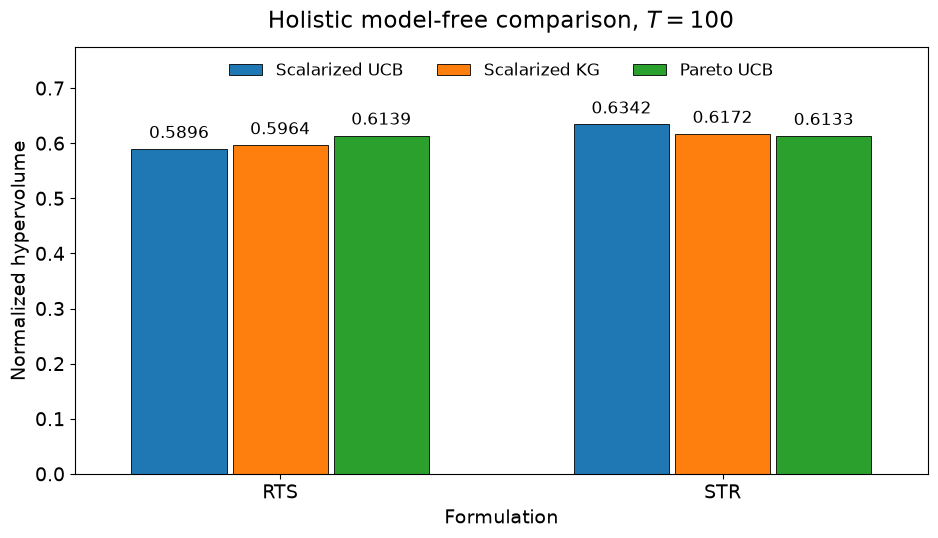

In [3]:
formulations = ("RTS", "STR")
algorithms = ("Scalarized UCB", "Scalarized KG", "Pareto UCB")
colors = ("#1f77b4", "#ff7f0e", "#2ca02c")
centers = np.array([0., 1.4])
width = .32
lookup = {(row["algorithm"], row["formulation"]): row["hypervolume"] for row in summary}
with plt.rc_context({"font.size": 14, "svg.fonttype": "none"}):
    fig, ax = plt.subplots(figsize=(9.6, 5.6))
    for i, (algorithm, color) in enumerate(zip(algorithms, colors)):
        values = [lookup[algorithm, formulation] for formulation in formulations]
        bars = ax.bar(centers + (i-1)*width, values, width=width*.94,
                      color=color, edgecolor="black", linewidth=.6, label=algorithm)
        ax.bar_label(bars, labels=[f"{value:.4f}" for value in values], padding=5, fontsize=12)
    ax.set_xticks(centers, formulations)
    ax.set_xlabel("Formulation")
    ax.set_ylabel("Normalized hypervolume")
    ax.set_title(r"Holistic model-free comparison, $T=100$", pad=14)
    ax.set_ylim(0, max(.05, max(lookup.values())*1.22))
    ax.set_xlim(-.65, 2.05)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.grid(False)
    ax.legend(loc="upper center", ncols=3, fontsize=12, frameon=False)
    fig.tight_layout()
    base = project_root / "Paper plots" / "Holistic model-free baseline comparison"
    fig.savefig(base.with_suffix(".png"), dpi=300, bbox_inches="tight")
    fig.savefig(base.with_suffix(".svg"), bbox_inches="tight")
    plt.show()


### Reproducibility and feedback check

The training files preserve every selected arm, current cost increments, and the final recommended set. Pareto UCB also stores each delayed observation's action and observation indices and the final pending action. The evaluation cache preserves all sampled sequences, seed lists, costs, and source/input hashes.


In [4]:
with (experiment_dir / "holistic Pareto UCB Pareto set.pkl").open("rb") as file:
    pareto = pickle.load(file)
training = pareto["training"]
delayed = training["delayed_observations"]
pairs = np.asarray([row["costs"] for row in delayed])
np.testing.assert_allclose(pairs[:, 0], training["increment_costs"][:-1, 0])
np.testing.assert_allclose(pairs[:, 1], training["increment_costs"][1:, 1])
np.testing.assert_array_equal([row["arm"] for row in delayed], training["arm_history"][:-1])
assert len(delayed) == 149 and training["pending_final_action"][0] == 149
rts_difference = max(abs(row["exact_mean_cost_hypervolume"] - row["quadrature_hypervolume"])
                     for row in summary if row["formulation"] == "RTS")
display(Markdown(f"Pareto UCB: **150 decisions, 149 completed delayed observations**, final action pending.\n\nMaximum exact-vs-quadrature RTS difference: **{rts_difference:.6g}**.\n\nShared held-out seeds: `{result['scenario_seeds']}`."))


Pareto UCB: **150 decisions, 149 completed delayed observations**, final action pending.

Maximum exact-vs-quadrature RTS difference: **1.35674e-05**.

Shared held-out seeds: `[2385971528, 3193148690, 3937333334, 2534194614, 797263586, 823411603, 2233374801, 2779230037, 3961860411, 1056997447]`.

## Cheetah reductionist approach

The same comparison is configured for **Cheetah**: $\gamma_{\mathrm{sync}}=\gamma_{\mathrm{grav}}=\gamma_{\mathrm{heter}}=1$, $M=40$, simulated rewards, **7 arms**, **7 scalarization directions**, and **150 Cheetah training requests**. The held-out horizon is **50 Cheetah requests**. The fixed reference costs are **(90,497.578125 KiB, 85)**, matching the existing reductionist comparisons.

Scalarized UCB and KG retain their current-request feedback. Only Pareto UCB pairs overhead at a Cheetah request with instability at the **next modeled Cheetah request**; its last action stays pending (149 observations for 150 decisions). Physical margins are used during simulation; normalized values are used for storage and sampling.

Each final arm set supplies **20 common random sequence draws**, deduplicated, with **10 shared held-out realizations per sequence**. Pareto UCB learns one set scored under both RTS and STR. These are single-training-run comparisons.

**Run the command below yourself from the project root**, then rerun this section to display the results. No reductionist experiment was executed while preparing it.

```cmd
".venv\Scripts\python.exe" -B "Model-free baseline\run_reductionist_comparison.py" --workers 4
```


### Load reductionist results

The following cells read the saved comparison when it is available. Before the command completes, they display a pending status without running simulations or plotting placeholder values.


In [1]:
from pathlib import Path
import importlib.util
import pickle
import sys
sys.dont_write_bytecode = True
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
red_root = next(root for root in (Path.cwd(), *Path.cwd().parents)
                if (root / "Model-free baseline" / "evaluate_reductionist_comparison.py").is_file())
red_dir = red_root / "Model-free baseline"
red_cache_path = red_dir / "reductionist hypervolume comparison.pkl"
red_result = None
red_summary = None
if not red_cache_path.exists():
    display(Markdown("**Pending:** run the reductionist comparison command above, then rerun this section."))
else:
    with red_cache_path.open("rb") as file:
        red_loaded = pickle.load(file)
    if not red_loaded.get("complete"):
        display(Markdown("**Pending:** the reductionist evaluation is still incomplete. Rerun the command to resume it."))
    else:
        sys.path.insert(0, str(red_dir))
        red_spec = importlib.util.spec_from_file_location("_reductionist_model_free_evaluation", red_dir / "evaluate_reductionist_comparison.py")
        red_comparison = importlib.util.module_from_spec(red_spec)
        sys.modules[red_spec.name] = red_comparison
        red_spec.loader.exec_module(red_comparison)
        assert red_loaded["kind"] == "reductionist_model_free_baseline_comparison"
        red_comparison.check_sources(red_loaded)
        red_result = red_loaded
        red_costs = np.asarray(red_result["cost_realizations"])
        assert np.isfinite(red_costs).all() and (red_costs >= 0).all()
        display(Markdown(f"**Completed reductionist evaluation:** {red_costs.shape[0]} unique sequences x {red_costs.shape[1]} shared realizations = **{red_costs.shape[0]*red_costs.shape[1]:,} simulations**."))


**Pending:** run the reductionist comparison command above, then rerun this section.

### Reductionist hypervolumes

RTS uses exact 2D hypervolume of per-sequence mean costs; STR uses the existing 128-direction expected-length calculation. All costs are divided by the shared reference above. The same Pareto UCB sequence measurements are used for both formulations.


In [2]:
if red_result is not None:
    red_summary = red_comparison.statistics(red_result)
    np.testing.assert_allclose([row["hypervolume"] for row in red_summary],
                               [row["hypervolume"] for row in red_result["summary"]], rtol=1e-12, atol=1e-14)
    red_table = ["| Algorithm | Formulation | Recommended arms | Unique sequences | Realizations | Hypervolume |",
                 "|:--|:--|:--|--:|--:|--:|"]
    for row in red_summary:
        red_table.append(f"| {row['algorithm']} | {row['formulation']} | {row['recommended_arm_indices'].tolist()} | {row['n_solutions']} | {row['n_realizations']} | {row['hypervolume']:.6f} |")
    display(Markdown("\n".join(red_table)))


### Reductionist comparison plot

The six bars compare Scalarized UCB, Scalarized KG, and Pareto UCB under RTS and STR, using the same plot style as the holistic comparison.


In [3]:
if red_summary is not None:
    red_formulations = ("RTS", "STR")
    red_algorithms = ("Scalarized UCB", "Scalarized KG", "Pareto UCB")
    red_colors = ("#1f77b4", "#ff7f0e", "#2ca02c")
    red_centers = np.array([0., 1.4])
    red_width = .32
    red_lookup = {(row["algorithm"], row["formulation"]): row["hypervolume"] for row in red_summary}
    with plt.rc_context({"font.size": 14, "svg.fonttype": "none"}):
        red_fig, red_ax = plt.subplots(figsize=(9.6, 5.6))
        for i, (algorithm, color) in enumerate(zip(red_algorithms, red_colors)):
            values = [red_lookup[algorithm, formulation] for formulation in red_formulations]
            bars = red_ax.bar(red_centers + (i-1)*red_width, values, width=red_width*.94,
                              color=color, edgecolor="black", linewidth=.6, label=algorithm)
            red_ax.bar_label(bars, labels=[f"{value:.4f}" for value in values], padding=5, fontsize=12)
        red_ax.set_xticks(red_centers, red_formulations)
        red_ax.set_xlabel("Formulation")
        red_ax.set_ylabel("Normalized hypervolume")
        red_ax.set_title(r"Cheetah model-free comparison, $T=50$", pad=14)
        red_ax.set_ylim(0, max(.05, max(red_lookup.values())*1.22))
        red_ax.set_xlim(-.65, 2.05)
        red_ax.ticklabel_format(axis="y", style="plain", useOffset=False)
        red_ax.grid(False)
        red_ax.legend(loc="upper center", ncols=3, fontsize=12, frameon=False)
        red_fig.tight_layout()
        red_base = red_root / "Paper plots" / "Reductionist model-free baseline comparison"
        red_fig.savefig(red_base.with_suffix(".png"), dpi=300, bbox_inches="tight")
        red_fig.savefig(red_base.with_suffix(".svg"), bbox_inches="tight")
        plt.show()


### Reductionist feedback verification

Check physical arm values and verify the next-request instability pairing from the saved Pareto UCB training record. This check does not rerun the environment.


In [4]:
if red_result is not None:
    with (red_dir / "reductionist Pareto UCB Pareto set.pkl").open("rb") as file:
        red_pareto = pickle.load(file)
    red_training = red_pareto["training"]
    red_pairs = np.asarray([row["costs"] for row in red_training["delayed_observations"]])
    np.testing.assert_allclose(red_pairs[:, 0], red_training["increment_costs"][:-1, 0])
    np.testing.assert_allclose(red_pairs[:, 1], red_training["increment_costs"][1:, 1])
    np.testing.assert_array_equal([row["arm"] for row in red_training["delayed_observations"]], red_training["arm_history"][:-1])
    assert len(red_pairs) == 149 and red_training["pending_final_action"][0] == 149
    np.testing.assert_allclose(red_pareto["arms_physical"], -10 + 30*red_pareto["arms_unit"])
    display(Markdown("**Verified:** physical Cheetah margins and 149 delayed observations from 150 decisions."))
